In [1]:
import os
import time
import json
import ast
import requests
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
API_KEY = "[]"
BASE_URL = "https://content.guardianapis.com/search"


In [3]:
DATA_DIR = Path("data/raw/guardian")

In [4]:
SLEEP_SECONDS = 1.1
PAGE_SIZE = 200

In [5]:
def guardian_get(params, sleep_seconds=SLEEP_SECONDS):
    params = params.copy()
    params["api-key"] = API_KEY

    resp = requests.get(BASE_URL, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    time.sleep(sleep_seconds)

    if data.get("response", {}).get("status") != "ok":
        raise RuntimeError(f"Unexpected API response: {data}")

    return data["response"]

In [6]:
def build_params(from_date, to_date, page=1, page_size=PAGE_SIZE):
    return {
        "section": "commentisfree",
        "type": "article",
        "from-date": from_date,
        "to-date": to_date,
        "use-date": "published",
        "order-by": "oldest",
        "page-size": page_size,
        "page": page,
        "show-fields": "headline,trailText,bodyText,byline",
        "show-tags": "keyword,contributor",
    }

In [7]:
def parse_result(result):
    fields = result.get("fields", {}) or {}
    tags = result.get("tags", []) or []

    keywords = [
        tag.get("webTitle")
        for tag in tags
        if tag.get("type") == "keyword"
    ]

    contributors = [
        tag.get("webTitle")
        for tag in tags
        if tag.get("type") == "contributor"
    ]

    return {
        "id": result.get("id"),
        "title": fields.get("headline") or result.get("webTitle"),
        "summary": fields.get("trailText"),
        "date": result.get("webPublicationDate"),
        "url": result.get("webUrl"),
        "author_raw": fields.get("byline"),
        "contributors": contributors,
        "n_contributors": len(contributors),
        "keywords": keywords,
        "body_text": fields.get("bodyText"),
        "section_id": result.get("sectionId"),
        "section_name": result.get("sectionName"),
    }

In [8]:
def fetch_year(year):
    from_date = f"{year}-01-01"
    to_date = f"{year}-12-31"

    # First call: get number of pages
    first_response = guardian_get(build_params(from_date, to_date, page=1, page_size=PAGE_SIZE))
    total = first_response.get("total", 0)
    pages = first_response.get("pages", 0)

    print(f"{year}: {total:,} results across {pages} pages")

    rows = [parse_result(r) for r in first_response.get("results", [])]

    for page in range(2, pages + 1):
        if page % 10 == 0 or page == pages:
            print(f"  fetching page {page}/{pages}")

        response = guardian_get(build_params(from_date, to_date, page=page, page_size=PAGE_SIZE))
        rows.extend(parse_result(r) for r in response.get("results", []))

    df = pd.DataFrame(rows).drop_duplicates(subset=["id"]).reset_index(drop=True)
    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
    df = df.sort_values("date").reset_index(drop=True)

    return df


In [9]:
def save_guardian_year(df_year, year, folder=DATA_DIR):
    df_save = df_year.copy()

    for col in ["keywords", "contributors"]:
        if col in df_save.columns:
            df_save[col] = df_save[col].apply(
                lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, list) else "[]"
            )

    out_path = Path(folder) / f"guardian_opinion_{year}.csv"
    df_save.to_csv(out_path, index=False)
    print(f"Saved {out_path}")

In [11]:
years = list(range(2005, 2010))

dfs = {}

for year in years:
    df_year = fetch_year(year)
    dfs[year] = df_year

    save_guardian_year(df_year, year, folder=DATA_DIR)

    print(f"{year} rows: {len(df_year):,}")
    print()

2005: 3 results across 1 pages
Saved data/raw/guardian/guardian_opinion_2005.csv
2005 rows: 3

2006: 7,964 results across 40 pages
  fetching page 10/40
  fetching page 20/40
  fetching page 30/40
  fetching page 40/40
Saved data/raw/guardian/guardian_opinion_2006.csv
2006 rows: 7,964

2007: 11,190 results across 56 pages
  fetching page 10/56
  fetching page 20/56
  fetching page 30/56
  fetching page 40/56
  fetching page 50/56
  fetching page 56/56
Saved data/raw/guardian/guardian_opinion_2007.csv
2007 rows: 11,190

2008: 12,674 results across 64 pages
  fetching page 10/64
  fetching page 20/64
  fetching page 30/64
  fetching page 40/64
  fetching page 50/64
  fetching page 60/64
  fetching page 64/64
Saved data/raw/guardian/guardian_opinion_2008.csv
2008 rows: 12,671

2009: 10,535 results across 53 pages
  fetching page 10/53
  fetching page 20/53
  fetching page 30/53
  fetching page 40/53
  fetching page 50/53
  fetching page 53/53
Saved data/raw/guardian/guardian_opinion_2009.

In [12]:
def parse_json_list_cell(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return []
    try:
        val = json.loads(s)
        return val if isinstance(val, list) else []
    except Exception:
        return []

def load_guardian_year(year, folder=DATA_DIR):
    path = Path(folder) / f"guardian_opinion_{year}.csv"
    df = pd.read_csv(path, keep_default_na=False)

    string_cols = [
        "id", "title", "summary", "url", "author_raw",
        "section_id", "section_name", "body_text"
    ]
    for col in string_cols:
        if col in df.columns:
            df[col] = df[col].astype("string")

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")

    for col in ["keywords", "contributors"]:
        if col in df.columns:
            df[col] = df[col].apply(parse_json_list_cell)

    if "n_contributors" in df.columns:
        df["n_contributors"] = pd.to_numeric(df["n_contributors"], errors="coerce").fillna(0).astype(int)

    df["year"] = int(year)
    return df

In [13]:
def load_guardian_years(years, folder=DATA_DIR, drop_duplicates=True):
    dfs = []

    for year in years:
        df_year = load_guardian_year(year, folder=folder)
        dfs.append(df_year)

    if not dfs:
        return pd.DataFrame()

    df = pd.concat(dfs, ignore_index=True)

    if drop_duplicates and "id" in df.columns:
        df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

    if "date" in df.columns:
        df = df.sort_values("date").reset_index(drop=True)

    return df

In [15]:
df_all = load_guardian_years(list(range(2005, 2026)), folder=DATA_DIR)

In [16]:
len(df_all)

155551

In [17]:
df_all.loc[df_all['n_contributors'] == 0 & df_all['author_raw'].isna() & (df_all['author_raw'] != "")]

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year


In [18]:
df_all.loc[df_all['body_text'].isna() | (df_all['body_text'].str.strip() == "")]

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year
28296,commentisfree/michaeltomasky/2008/oct/02/usele...,Tomasky talk: Palin v Biden,<p><strong>Tomasky talk:</strong> As Joe Biden...,2008-10-02 00:00:02+00:00,https://www.theguardian.com/commentisfree/mich...,Michael Tomasky,[Michael Tomasky],1,"[US elections 2008, Joe Biden, Sarah Palin, Re...",,commentisfree,Opinion,2008
37851,commentisfree/libertycentral/2009/jun/15/refug...,'Displacement is not new',<p><strong>Video: Refugee Week 2009: </strong>...,2009-06-15 11:53:32+00:00,https://www.theguardian.com/commentisfree/libe...,Rowan Williams,[Rowan Williams],1,"[Refugees, Immigration and asylum, UK civil li...",,commentisfree,Opinion,2009
50194,commentisfree/2010/oct/22/comic-sans-type-ligh...,Comic Sans not your type? Lighten up,<p><strong>Dan Hancox:</strong> What does it s...,2010-10-22 13:15:43+00:00,https://www.theguardian.com/commentisfree/2010...,Dan Hancox,[Dan Hancox],1,"[Design, Art and design, Culture, World news, ...",,commentisfree,Opinion,2010
50350,commentisfree/belief/2010/oct/27/religion,An interview with Stanley Hauerwas,<p><strong>Video:</strong> Theologian Stanley ...,2010-10-27 13:31:50+00:00,https://www.theguardian.com/commentisfree/beli...,,[],0,"[Religion, World news]",,commentisfree,Opinion,2010
56981,commentisfree/2011/jun/30/are-you-on-strike-to...,Are you on strike today? Tell us why,<p>We asked readers to tell us why they were s...,2011-06-30 09:49:00+00:00,https://www.theguardian.com/commentisfree/2011...,Jessica Reed and Bella Mackie,"[Jessica Reed, Bella Mackie]",2,"[Trade unions, TUC, Public sector cuts, Public...",,commentisfree,Opinion,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145569,commentisfree/2023/nov/13/people-who-build-win...,People who build wind turbines at sea do not c...,Donald Trump said it so it must be true,2023-11-13 05:52:59+00:00,https://www.theguardian.com/commentisfree/2023...,First Dog on the Moon,[First Dog on the Moon],1,"[Wind power, Energy, Environment, Renewable en...",,commentisfree,Opinion,2023
145597,commentisfree/2023/nov/15/dingo-fans-rejoice-a...,Dingo fans rejoice: a dingo is finally going t...,It will certainly feel right at home surrounde...,2023-11-15 05:51:16+00:00,https://www.theguardian.com/commentisfree/2023...,First Dog on the Moon,[First Dog on the Moon],1,"[Wildlife, Endangered species, Animals]",,commentisfree,Opinion,2023
145663,commentisfree/2023/nov/20/record-profits-you-c...,RECORD PROFITS! You could have used that money...,Isn’t there a cost of living crisis?!<br>,2023-11-20 06:11:37+00:00,https://www.theguardian.com/commentisfree/2023...,First Dog on the Moon,[First Dog on the Moon],1,"[Cost-of-living crisis, Inequality, Banking , ...",,commentisfree,Opinion,2023
145683,commentisfree/2023/nov/21/who-is-the-worlds-wo...,Who is the world’s worst carbon foot prince? W...,"Who emits more greenhouse gas, is it 1.8 milli...",2023-11-21 13:00:15+00:00,https://www.theguardian.com/commentisfree/2023...,First Dog on the Moon,[First Dog on the Moon],1,"[Greenhouse gas emissions, Fossil fuels, The s...",,commentisfree,Opinion,2023


In [19]:
def get_top_authors(df, author_col="contributors", top_n=50, drop_empty=True):
    """
    Count how many articles each author contributed to.

    Parameters
    ----------
    df : pd.DataFrame
        Guardian articles dataframe
    author_col : str
        Column containing a list of contributors
    top_n : int
        Number of top authors to return
    drop_empty : bool
        Whether to exclude empty/missing contributor names

    Returns
    -------
    pd.DataFrame
        Columns: contributor, n_articles
    """
    if author_col not in df.columns:
        raise ValueError(f"Column '{author_col}' not found in dataframe.")

    author_series = df[author_col].copy()

    # Make sure each cell is a list
    author_series = author_series.apply(
        lambda x: x if isinstance(x, list) else []
    )

    # One row per (article, contributor)
    exploded = df[["id", author_col]].copy()
    exploded[author_col] = author_series
    exploded = exploded.explode(author_col)

    # Clean names
    exploded[author_col] = exploded[author_col].astype("string").str.strip()

    if drop_empty:
        exploded = exploded[
            exploded[author_col].notna() &
            (exploded[author_col] != "")
        ]

    # Count unique articles per contributor
    top_authors = (
        exploded.groupby(author_col)["id"]
        .nunique()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={author_col: "contributor", "id": "n_articles"})
    )

    return top_authors.head(top_n)

In [20]:
authors_article_count = get_top_authors(df_all, author_col="contributors", top_n=100000)
authors_article_count.head(50)

,contributor,n_articles
0,Editorial,8111
1,Simon Jenkins,1890
2,Michael Tomasky,1848
3,Polly Toynbee,1735
4,Zoe Williams,1522
5,Martin Kettle,1282
6,Arwa Mahdawi,1265
7,Jonathan Freedland,1148
8,Observer editorial,1101
9,Catherine Bennett,1014


In [21]:
authors_article_count.describe()

,n_articles
count,18988.000000
mean,7.474352
std,74.535087
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,8111.000000


In [22]:
authors_article_count[authors_article_count["n_articles"] > 20]

,contributor,n_articles
0,Editorial,8111
1,Simon Jenkins,1890
2,Michael Tomasky,1848
3,Polly Toynbee,1735
4,Zoe Williams,1522
...,...,...
881,Robert McCrum,21
882,Patrick Diamond,21
883,Peter Geoghegan,21
884,Indra Adnan,21


In [23]:
authors_article_count = authors_article_count[1:]

<Axes: xlabel='n_articles', ylabel='Count'>

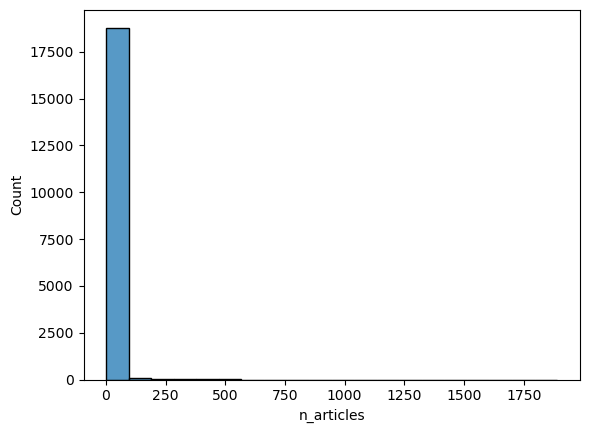

In [24]:
sns.histplot(authors_article_count["n_articles"], bins=20)

In [25]:
df_all.to_parquet(Path("data/raw/guardian_opinion_2005_2025.parquet"), index=False)